In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score


from scipy import stats
from scipy.stats import linregress
import statsmodels.api as sm

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Reading data

In [3]:
Deseq_VST = pd.read_csv('../data/PsychENCODE-pyDeSeq2.VST.csv', index_col=0)
Deseq_VST.index.name = 'individualID'

In [4]:
PsychENCODE_Metadata = pd.read_csv('../data/PsychENCODE-Metadata.csv')

PsychENCODE_Metadata.set_index('individualID', inplace=True)

PsychENCODE_Metadata = PsychENCODE_Metadata.loc[Deseq_VST.index,:]

PsychENCODE_Metadata = PsychENCODE_Metadata.loc[PsychENCODE_Metadata.ageDeath != '90+', :]
PsychENCODE_Metadata = PsychENCODE_Metadata.loc[~PsychENCODE_Metadata.ageDeath.isna(), :]
PsychENCODE_Metadata.ageDeath = PsychENCODE_Metadata.ageDeath.astype(int)

<Axes: xlabel='ageDeath', ylabel='Count'>

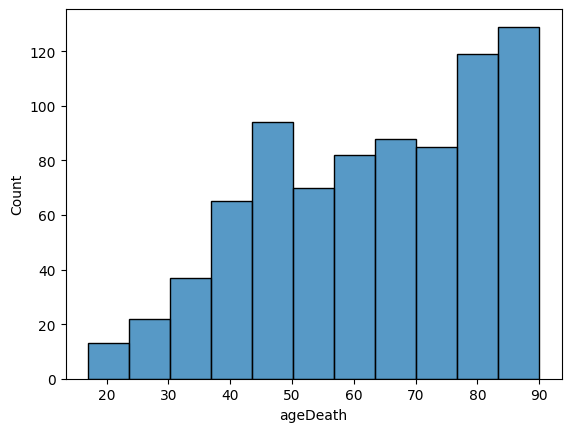

In [5]:
sns.histplot(PsychENCODE_Metadata.ageDeath)

# Elastic Net

In [6]:
PsychENCODE_Metadata['age_cohort'] = np.nan
PsychENCODE_Metadata.loc[PsychENCODE_Metadata.ageDeath <= 40, 'age_cohort'] = 'young'
PsychENCODE_Metadata.loc[PsychENCODE_Metadata.ageDeath > 40, 'age_cohort'] = 'old'

In [7]:
scaler = StandardScaler()
Xs = scaler.fit_transform(Deseq_VST)

In [8]:
Deseq_VST_scaled = pd.DataFrame(Xs, index = Deseq_VST.index, columns = Deseq_VST.columns)

In [9]:
Model_df = Deseq_VST_scaled.merge(PsychENCODE_Metadata[['primaryDiagnosis', 'ageDeath', 'age_cohort']], on='individualID')

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(Model_df.query('primaryDiagnosis == "control"'),
                                                    Model_df.query('primaryDiagnosis == "control"')['ageDeath'], 
                                                    test_size=0.3, random_state=42, 
                                                    stratify=Model_df.query('primaryDiagnosis == "control"').age_cohort)

In [11]:
X_train_clean = X_train.iloc[:, :-3]

X_test_clean = X_test.iloc[:, :-3]

In [12]:
X_test = Model_df.loc[~Model_df.index.isin(X_train_clean.index)]
X_test_clean = X_test.iloc[:, :-3]

In [13]:
random_state = 42
cv = KFold(n_splits=min(5, max(2, len(y_train)//2)), shuffle=True, random_state=random_state)
EN_model = ElasticNetCV(l1_ratio=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9], 
                     alphas=np.logspace(-3,2,30), 
                     cv = cv, 
                     random_state = random_state, 
                     max_iter = 10_000,
                     n_jobs = 16)
EN_model.fit(X_train_clean, y_train)

ElasticNetCV(alphas=array([1.00000000e-03, 1.48735211e-03, 2.21221629e-03, 3.29034456e-03,
       4.89390092e-03, 7.27895384e-03, 1.08263673e-02, 1.61026203e-02,
       2.39502662e-02, 3.56224789e-02, 5.29831691e-02, 7.88046282e-02,
       1.17210230e-01, 1.74332882e-01, 2.59294380e-01, 3.85662042e-01,
       5.73615251e-01, 8.53167852e-01, 1.26896100e+00, 1.88739182e+00,
       2.80721620e+00, 4.17531894e+00, 6.21016942e+00, 9.23670857e+00,
       1.37382380e+01, 2.04335972e+01, 3.03919538e+01, 4.52035366e+01,
       6.72335754e+01, 1.00000000e+02]),
             cv=KFold(n_splits=5, random_state=42, shuffle=True),
             l1_ratio=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
             max_iter=10000, n_jobs=16, random_state=42)

In [14]:
y_pred = EN_model.predict(X_test_clean)

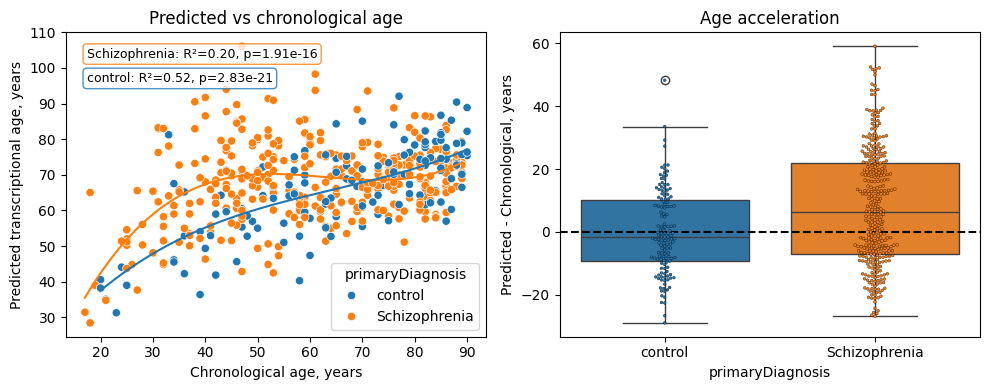

In [15]:
results = []

sub = X_test.copy()
sub['predicted_age'] = y_pred
sub['age_acceleration'] = sub['predicted_age'] - sub['ageDeath'].astype(float)

group_ctrl = sub[sub['primaryDiagnosis'].astype(str).str.lower().isin(['control'])]['age_acceleration'].dropna().values
group_dis = sub[~sub['primaryDiagnosis'].astype(str).str.lower().isin(['control'])]['age_acceleration'].dropna().values

u_stat, p_val = stats.mannwhitneyu(group_dis, group_ctrl, nan_policy='omit')
median_stat, p_val_median = stats.median_test(group_dis, group_ctrl, nan_policy='omit')[:2]

results.append({
    'n_samples': sub['sampleID'].nunique() if 'sampleID' in sub.columns else len(sub),
    'model_alpha': float(EN_model.alpha_),
    'model_l1_ratio': float(EN_model.l1_ratio_),
    'mean_acc_ctrl': np.nanmean(group_ctrl) if len(group_ctrl)>0 else np.nan,
    'median_acc_ctrl': np.nanmedian(group_ctrl) if len(group_ctrl)>0 else np.nan,
    'mean_acc_disease': np.nanmean(group_dis) if len(group_dis)>0 else np.nan,
    'median_acc_disease': np.nanmedian(group_dis) if len(group_dis)>0 else np.nan,
    'U_stat': float(u_stat) if not np.isnan(u_stat) else np.nan,
    'p_val_mannwhitneyu': float(p_val) if not np.isnan(p_val) else np.nan,
    'median_stat': float(median_stat) if not np.isnan(median_stat) else np.nan,
    'p_val_median': float(p_val_median) if not np.isnan(p_val_median) else np.nan,
})

fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.scatterplot(x=sub['ageDeath'], y=sub['predicted_age'], hue=sub['primaryDiagnosis'], ax=axes[0])
axes[0].set_title("Predicted vs chronological age")
axes[0].set_xlabel("Chronological age, years")
axes[0].set_ylabel("Predicted transcriptional age, years")

sns.boxplot(data=sub, y="age_acceleration", x="primaryDiagnosis", hue="primaryDiagnosis", ax=axes[1])
sns.swarmplot(data=sub, x="primaryDiagnosis", y="age_acceleration", hue="primaryDiagnosis", size=2, edgecolor='k', linewidth=0.25, ax=axes[1])

axes[1].axhline(0, ls='--', color='k')
axes[1].set_title("Age acceleration")
axes[1].set_ylabel("Predicted - Chronological, years")
plt.tight_layout()

palette = dict(zip(
    sub["primaryDiagnosis"].unique(),
    sns.color_palette(n_colors=sub["primaryDiagnosis"].nunique())
))

order = 3  
for i, (status, df) in enumerate(sub.groupby("primaryDiagnosis")):

    X = df["ageDeath"].values.reshape(-1, 1)
    y = df["predicted_age"].values

    poly = PolynomialFeatures(degree=order)
    X_poly = poly.fit_transform(X)

    model = sm.OLS(y, X_poly).fit()

    y_pred_ols = model.predict(X_poly)
    r2 = r2_score(y, y_pred_ols)

    x_range = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    x_poly = poly.transform(x_range)
    y_range = model.predict(x_poly)
    axes[0].plot(x_range, y_range, color=palette[status], label=f"{status} trend")

    p_value = model.f_pvalue  

    axes[0].text(
        0.05, 0.95 - i*0.08, 
        f"{status}: R²={r2:.2f}, p={p_value:.3g}", 
        transform=axes[0].transAxes, 
        color="black", 
        fontsize=9, 
        verticalalignment="top",
        bbox=dict(
            facecolor="white", 
            edgecolor=palette[status], 
            boxstyle="round,pad=0.3", 
            alpha=0.8
        )
    )

plt.show()
plt.close(fig)  # avoid auto-show in non-interactive environments

In [16]:
sub.iloc[:, [-5,-4,-3,-2,-1]].to_csv('results/ElasticNet.Prediction.csv')

In [17]:
results = pd.DataFrame(results)
results.to_csv('results/ElasticNet.ResultStatistics.csv')
results

,n_samples,model_alpha,model_l1_ratio,mean_acc_ctrl,median_acc_ctrl,mean_acc_disease,median_acc_disease,U_stat,p_val_mannwhitneyu,median_stat,p_val_median
0,480,0.853168,0.9,-0.156188,-1.65097,7.781869,6.346697,29409.0,0.000034,13.124328,0.000291


In [18]:
Coef_df = pd.DataFrame({'coef':EN_model.coef_}, index=X_test_clean.columns)
Coef_df = Coef_df.sort_values(by='coef', ascending=False)
Coef_df.to_csv('results/ElasticNet.Coefficients.csv')